29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Denoising Autoencoder...
Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.4083 - val_loss: 0.3442
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.3321 - val_loss: 0.3285
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.3223 - val_loss: 0.3213
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.3160 - val_loss: 0.3160
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.3113 - val_loss: 0.3120
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


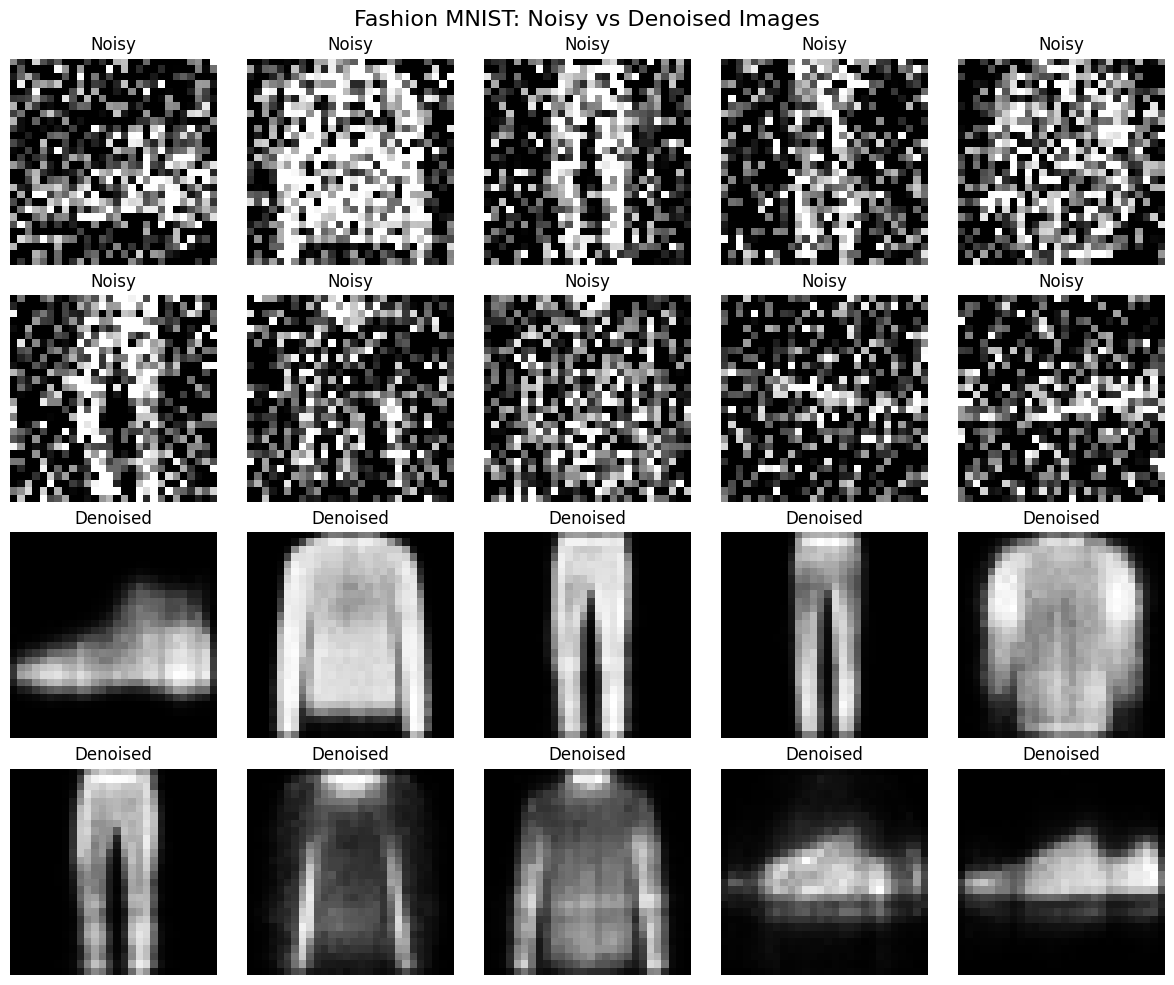

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers


# ============================================================
# DENOISING AUTOENCODER - FASHION MNIST
# ============================================================

# 1. Load Fashion MNIST dataset
(x_train, _), (x_test, _) = keras.datasets.fashion_mnist.load_data()


# ============================================================
# 2. Normalize pixel values from [0, 255] to [0, 1]
# ============================================================

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0


# ============================================================
# 3. Add random noise to training images
# ============================================================

noise_factor = 0.5

# Generate random Gaussian noise
noise_train = noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

# Add noise to training images
x_train_noisy = x_train + noise_train

# Keep pixel values between 0 and 1
x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)


# ============================================================
# 4. Add random noise to test images
# ============================================================

noise_test = noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

x_test_noisy = x_test + noise_test

# Keep pixel values between 0 and 1
x_test_noisy = np.clip(x_test_noisy, 0.0, 1.0)


# ============================================================
# 5. Flatten images from 28x28 to 784
# ============================================================

x_train_noisy_flat = x_train_noisy.reshape(-1, 28 * 28)
x_train_flat = x_train.reshape(-1, 28 * 28)

x_test_noisy_flat = x_test_noisy.reshape(-1, 28 * 28)
x_test_flat = x_test.reshape(-1, 28 * 28)


# ============================================================
# 6. Build the Autoencoder
# ============================================================

input_img = keras.Input(shape=(784,))

# Encoder
encoded = layers.Dense(
    64,
    activation="relu"
)(input_img)

# Decoder
decoded = layers.Dense(
    784,
    activation="sigmoid"
)(encoded)

# Complete autoencoder
autoencoder = keras.Model(
    input_img,
    decoded
)


# ============================================================
# 7. Compile the Autoencoder
# ============================================================

autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)


# ============================================================
# 8. Train the Denoising Autoencoder
# ============================================================

print("Training Denoising Autoencoder...")

history = autoencoder.fit(
    x_train_noisy_flat,     # Noisy images as input
    x_train_flat,           # Clean images as target
    epochs=5,
    batch_size=256,
    shuffle=True,
    validation_data=(
        x_test_noisy_flat,
        x_test_flat
    )
)


# ============================================================
# 9. Denoise 10 test images
# ============================================================

denoised = autoencoder.predict(
    x_test_noisy_flat
)


# ============================================================
# 10. Display 10 noisy and denoised images
# ============================================================

plt.figure(figsize=(12, 10))

for i in range(10):

    # Noisy image
    plt.subplot(4, 5, i + 1)

    plt.imshow(
        x_test_noisy[i],
        cmap="gray"
    )

    plt.title("Noisy")
    plt.axis("off")


    # Denoised image
    plt.subplot(4, 5, i + 11)

    plt.imshow(
        denoised[i].reshape(28, 28),
        cmap="gray"
    )

    plt.title("Denoised")
    plt.axis("off")


plt.suptitle(
    "Fashion MNIST: Noisy vs Denoised Images",
    fontsize=16
)

plt.tight_layout()
plt.show()